In [66]:
%matplotlib inline
import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import heapq
import random

### 1. Warehouse Map

- กำหนดโครงสร้างแผนที่ตารางกริดของคลังสินค้า

In [67]:
warehouse = np.array([
    [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0]
])

### 2. Coordinate Validation

- ตรวจสอบความถูกต้องของตำแหน่งทางเข้า ทางออก และชั้นวางสินค้า

In [68]:
def validate_points(warehouse, entrance, exit_point, pickup_points):
    if warehouse[entrance] != 0: raise ValueError("Entrance must be on walkway (0)")
    if warehouse[exit_point] != 0: raise ValueError("Exit must be on walkway (0)")
    for point in pickup_points:
        if warehouse[point] != 1: raise ValueError(f"Pickup point {point} must be on shelf (1)")

### 3. Random Pickup Point Generation

- สุ่มจุดหยิบสินค้าตามจำนวนที่ต้องการพร้อมล็อกค่า seed

In [69]:
def generate_pickup_points(warehouse, n, seed=42):
    shelf_positions = list(zip(*np.where(warehouse == 1)))
    rng = np.random.default_rng(seed)
    selected_indices = rng.choice(len(shelf_positions), size=n, replace=False)
    return [shelf_positions[index] for index in selected_indices]

### 4. Warehouse Map Visualization

- ฟังก์ชันแปลงข้อมูลเป็นภาพกราฟิก

In [70]:
def plot_warehouse(warehouse, entrance, exit_point, pickup_points):
    rows, cols = warehouse.shape
    colors = ["#EAF6FF", "#4A4A4A"]
    warehouse_cmap = ListedColormap(colors)
    plt.figure(figsize=(12, 8))
    plt.imshow(warehouse, cmap=warehouse_cmap, origin="upper", interpolation="nearest")
    
    plt.scatter(entrance[1], entrance[0], color="#27AE60", s=220, edgecolors="black", zorder=3)
    plt.text(entrance[1], entrance[0], "IN", ha="center", va="center", color="white", fontweight="bold", fontsize=8, zorder=4)
    
    plt.scatter(exit_point[1], exit_point[0], color="#E74C3C", s=220, edgecolors="black", zorder=3)
    plt.text(exit_point[1], exit_point[0], "OUT", ha="center", va="center", color="white", fontweight="bold", fontsize=7, zorder=4)
    
    for index, point in enumerate(pickup_points, start=1):
        plt.scatter(point[1], point[0], color="#F1C40F", s=180, marker="s", edgecolors="black", zorder=3)
        plt.text(point[1], point[0], str(index), ha="center", va="center", fontweight="bold", color="black", zorder=4)

    plt.xticks(np.arange(-0.5, cols, 1), minor=True)
    plt.yticks(np.arange(-0.5, rows, 1), minor=True)
    plt.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    plt.title("Warehouse Map with Entrance, Exit and Pickup Points", fontsize=14, fontweight="bold")
    
    legend_elements = [
        Patch(facecolor="#EAF6FF", edgecolor="black", label="Walkway (0)"),
        Patch(facecolor="#4A4A4A", edgecolor="black", label="Shelf (1)"),
        plt.Line2D([0], [0], marker="o", color="w", label="Entrance", markerfacecolor="#27AE60", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w", label="Exit", markerfacecolor="#E74C3C", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="s", color="w", label="Pickup Point", markerfacecolor="#F1C40F", markeredgecolor="black", markersize=10)
    ]
    
    plt.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=5)
    plt.show()

### 5. Initialize Coordinates and Display Map

- แสดงภาพแผนที่

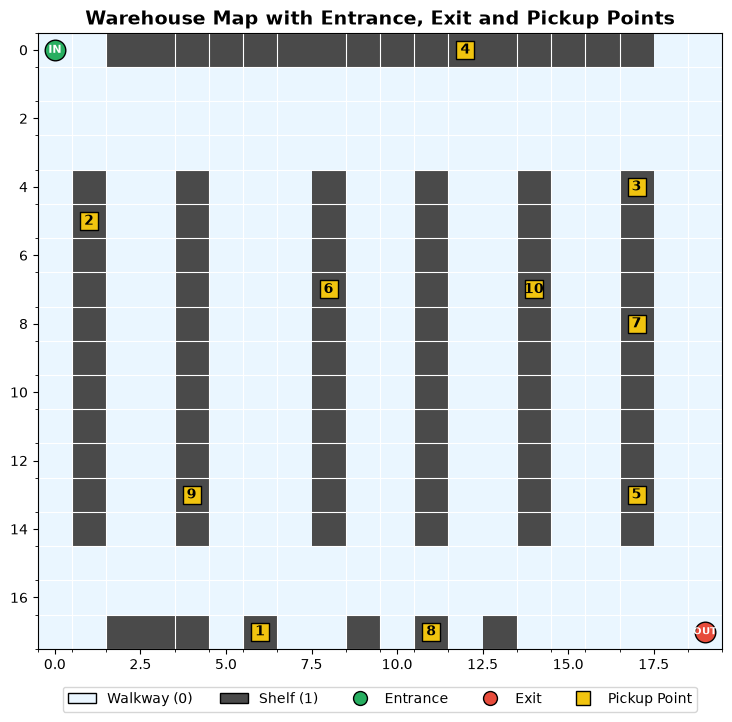

In [71]:
entrance = (0, 0)
exit_point = (17, 19)
n = 10

pickup_points = generate_pickup_points(warehouse=warehouse, n=n, seed=20)

validate_points(warehouse, entrance, exit_point, pickup_points)  
plot_warehouse(warehouse, entrance, exit_point, pickup_points) 

### 6. Print Pickup Coordinates

- แสดงพิกัดตัวเลข (Row, Column) ของจุดหยิบสินค้าทั้งหมด

In [72]:
print("Entrance:", entrance)
print("Exit:", exit_point)
for index, point in enumerate(pickup_points, start=1):
    print(f"  Pickup {index}: ({int(point[0])}, {int(point[1])})")

Entrance: (0, 0)
Exit: (17, 19)
  Pickup 1: (17, 6)
  Pickup 2: (5, 1)
  Pickup 3: (4, 17)
  Pickup 4: (0, 12)
  Pickup 5: (13, 17)
  Pickup 6: (7, 8)
  Pickup 7: (8, 17)
  Pickup 8: (17, 11)
  Pickup 9: (13, 4)
  Pickup 10: (7, 14)


### 7. Stand Position Finder

- ค้นหาพิกัดจุดยืนหยิบสินค้าที่อยู่ติดกับชั้นวางสินค้า เพื่อเตรียมให้พนักงานยืนหยิบของ

In [73]:
def get_valid_stand_positions(warehouse, item_pos):
    stand_positions = []
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    for dr, dc in directions:
        nr, nc = item_pos[0] + dr, item_pos[1] + dc
        if 0 <= nr < warehouse.shape[0] and 0 <= nc < warehouse.shape[1]:
            if warehouse[nr, nc] == 0:
                stand_positions.append((nr, nc))
    return stand_positions

### 8. Shortest Path Calculation

- ใช้ A* Search คำนวณหาเส้นทางและระยะทางที่สั้นที่สุดบนแผนที่ตารางกริดระหว่างจุดเริ่มต้นและจุดหมาย

In [74]:
def a_star_search(warehouse, starts, targets):
    def heuristic(pos):
        return min(abs(pos[0] - t[0]) + abs(pos[1] - t[1]) for t in targets)
    
    pq = []
    visited = set()
    counter = 0 
    for st in starts:
        heapq.heappush(pq, (heuristic(st), 0, counter, st, [st]))
        counter += 1
        
    while pq:
        f, g, _, curr, path = heapq.heappop(pq)
        
        if curr in targets:
            return g, path
            
        if curr in visited:
            continue
        visited.add(curr)
        
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = curr[0] + dr, curr[1] + dc
            if 0 <= nr < warehouse.shape[0] and 0 <= nc < warehouse.shape[1]:
                if warehouse[nr, nc] == 0 and (nr, nc) not in visited:
                    new_g = g + 1
                    new_f = new_g + heuristic((nr, nc))
                    heapq.heappush(pq, (new_f, new_g, counter, (nr, nc), path + [(nr, nc)]))
                    counter += 1
    return float('inf'), []

### 9. Distance Matrix Generator

- ฟังก์ชันรวบรวมโหนดสำคัญทั้งหมด (ทางเข้า, จุดหยิบสินค้า, ทางออก) 

- นำ A* Search มาใช้งานเพื่อคำนวณตารางระยะทางจริงระหว่างทุกๆ จุด

In [75]:
def build_distance_matrix(warehouse, entrance, exit_point, pickup_points):
    all_nodes = [entrance] + pickup_points + [exit_point]
    num_nodes = len(all_nodes)
    dist_matrix = np.zeros((num_nodes, num_nodes))
    valid_positions = []
    
    for i, node in enumerate(all_nodes):
        if i == 0 or i == num_nodes - 1:
            valid_positions.append([node])
        else:
            valid_positions.append(get_valid_stand_positions(warehouse, node))
            
    print("[System] Generating Distance Matrix with A* Search...")
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j:
                dist_matrix[i][j] = 0
            elif i < j:
                dist, _ = a_star_search(warehouse, valid_positions[i], valid_positions[j])
                dist_matrix[i][j] = dist
                dist_matrix[j][i] = dist 
                
    return dist_matrix, valid_positions

### 10. Generate and Display Distance Matrix

- ประมวลผลและแสดงผลตารางระยะทาง (Distance Matrix) ออกมาในรูปแบบภาพฮีทแมพ (Heatmap Visualization) เพื่อให้เห็นเปรียบเทียบระยะทางระหว่างจุดต่างๆ ได้

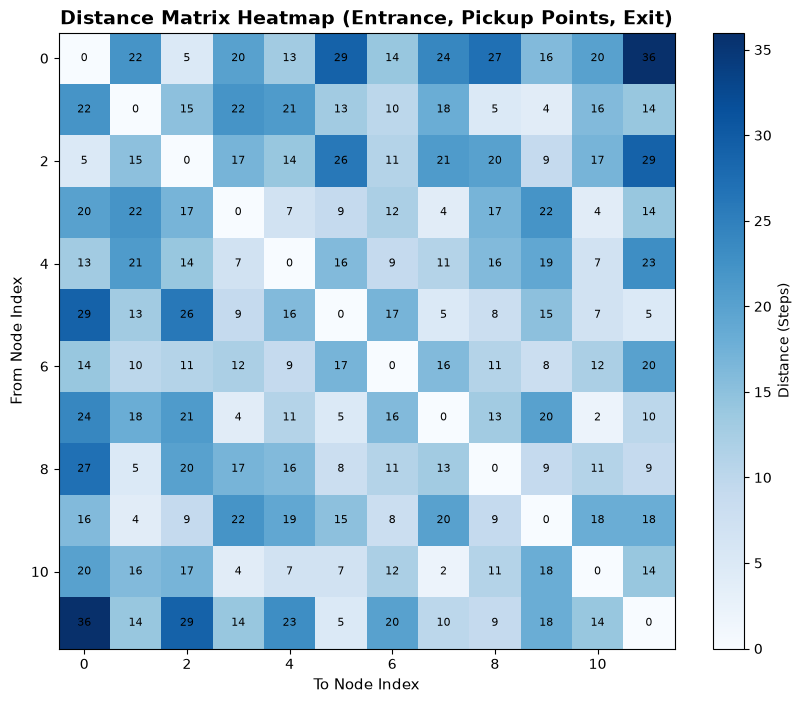

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(dist_matrix, cmap="Blues", interpolation="nearest")
plt.colorbar(label="Distance (Steps)")

for i in range(dist_matrix.shape[0]):
    for j in range(dist_matrix.shape[1]):
        plt.text(j, i, f"{int(dist_matrix[i, j])}", ha="center", va="center", color="black", fontsize=8)

plt.title("Distance Matrix Heatmap (Entrance, Pickup Points, Exit)", fontsize=14, fontweight="bold")
plt.xlabel("To Node Index", fontsize=11)
plt.ylabel("From Node Index", fontsize=11)
plt.show()